# Phase 3c — SMA 리스크룰 보강 재검증 (BTC + ETH 4h)

## 목적

Phase 3에서 **SMA Cross (손절 없음)는 탈락**했다. 탈락 사유 두 가지:
1. 리스크룰 부재 (CLAUDE.md 가드레일 5 위반)
2. 워크포워드 일관성 부족 (BTC 2/5구간만 방어)

→ **손절 5% 추가(`SmaCrossWithStop`)** 로 이 둘이 해소되는지 견고성 3축으로 재검증.
→ BTC 통과 시 ETH(out-of-asset)에서도 동일 기준으로 재현 여부 확인.

### 탈락 기준 (사전 확정)
1. **OOS (70/30)**: OOS 구간에서 B&H 대비 MDD 방어 재현 (절대수익 음수 허용)
2. **민감도 (단일 spike 아님)**:
   - 손절 민감도: stop ∈ {3%, 5%, 8%} 전 구간 방어 방향 일치
   - MA grid: `fast {10,15,20,30} × slow {40,50,60,100}` 중 ≥60%가 B&H MDD 방어
3. **워크포워드**: 5구간 중 ≥3구간 방어
4. **ETH 재현** (BTC 통과 시만): ETH 4h에서 1~3 동일 기준 통과

> 손절 최적값(3%)은 채택하지 않는다. 5%는 사전 고정값.

In [1]:
import warnings
warnings.filterwarnings("ignore", message="Some trades remain open at the end of backtest")
warnings.filterwarnings("ignore", message="Jupyter Notebook detected")
warnings.filterwarnings("ignore", category=UserWarning, module="matplotlib")
warnings.filterwarnings("ignore", category=UserWarning, module="IPython")

import os, sys
if os.path.basename(os.getcwd()) == "research":
    os.chdir("..")
sys.path.insert(0, os.getcwd())

import matplotlib
matplotlib.use("Agg")
%matplotlib inline

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

from backtest import load_data
from robustness import (train_test_split, evaluate, param_sweep, walk_forward, buy_hold)
from strategies.sma_cross_stop import SmaCrossWithStop
from strategies.sma_cross import SmaCross

pd.set_option("display.width", 200)
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", "{:.1f}".format)

btc = load_data("BTC/USDT", "4h")
eth = load_data("ETH/USDT", "4h")
print(f"BTC: {len(btc)} bars  {btc.index[0].date()} ~ {btc.index[-1].date()}")
print(f"ETH: {len(eth)} bars  {eth.index[0].date()} ~ {eth.index[-1].date()}")

Loading BokehJS ...

BTC: 10949 bars  2021-06-28 ~ 2026-06-27
ETH: 10949 bars  2021-06-29 ~ 2026-06-28


---

## 손절 효과 — SMA (no stop) vs SMA+stop 5% (full, 20/50)

손절 추가가 두 자산에서 뭘 바꿨나.

In [2]:
rows = []
for sym, df in [("BTC", btc), ("ETH", eth)]:
    m_no   = evaluate(df, SmaCross, fast=20, slow=50)
    m_stop = evaluate(df, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
    bh     = buy_hold(df)
    rows.append({
        "자산": sym,
        "SMA 수익%":       round(m_no["Return [%]"], 1),
        "SMA MDD%":       round(m_no["Max. Drawdown [%]"], 1),
        "SMA Sharpe":     round(m_no["Sharpe Ratio"], 2),
        "SMA+stop 수익%": round(m_stop["Return [%]"], 1),
        "SMA+stop MDD%": round(m_stop["Max. Drawdown [%]"], 1),
        "SMA+stop Sharpe": round(m_stop["Sharpe Ratio"], 2),
        "B&H 수익%":      round(bh["Return [%]"], 1),
        "B&H MDD%":      round(bh["Max. Drawdown [%]"], 1),
    })

cmp = pd.DataFrame(rows).set_index("자산")
display(cmp)
print()
print("손절 추가 효과:")
for sym, df in [("BTC", btc), ("ETH", eth)]:
    m_no   = evaluate(df, SmaCross, fast=20, slow=50)
    m_stop = evaluate(df, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
    ret_diff = m_stop["Return [%]"] - m_no["Return [%]"]
    mdd_diff = m_no["Max. Drawdown [%]"] - m_stop["Max. Drawdown [%]"]
    print(f"  {sym}: 수익 {ret_diff:+.1f}%p 개선, MDD {mdd_diff:+.1f}%p 개선")

,SMA 수익%,SMA MDD%,SMA Sharpe,SMA+stop 수익%,SMA+stop MDD%,SMA+stop Sharpe,B&H 수익%,B&H MDD%
자산,,,,,,,,
BTC,18.9,-60.1,0.1,45.4,-53.5,0.2,75.3,-77.0
ETH,-41.3,-71.4,-0.2,50.5,-45.6,0.2,-27.6,-81.1



손절 추가 효과:
  BTC: 수익 +26.4%p 개선, MDD -6.6%p 개선


  ETH: 수익 +91.8%p 개선, MDD -25.8%p 개선


---

## BTC 검증 (3축)

### 축 1 — OOS (70/30)

In [3]:
btc_train, btc_test = train_test_split(btc, 0.7)

def make_oos_table(df, strategy, **params):
    tr, te = train_test_split(df, 0.7)
    rows = []
    labels_data = [
        (f"FULL ({df.index[0].date()}~{df.index[-1].date()})", df),
        (f"IS  앞70% ({tr.index[0].date()}~{tr.index[-1].date()})", tr),
        (f"OOS 뒤30% ({te.index[0].date()}~{te.index[-1].date()})", te),
    ]
    for label, d in labels_data:
        m  = evaluate(d, strategy, **params)
        bh = buy_hold(d)
        # MDD는 음수. 전략 MDD > B&H MDD → 전략이 덜 내림 = 방어
        defend_pp = m["Max. Drawdown [%]"] - bh["Max. Drawdown [%]"]
        rows.append({
            "구간": label,
            "봉수": len(d),
            "전략 수익%":  round(m["Return [%]"], 1),
            "전략 MDD%":  round(m["Max. Drawdown [%]"], 1),
            "Sharpe":     round(m["Sharpe Ratio"], 2),
            "거래수":     int(m["# Trades"]),
            "B&H 수익%":  round(bh["Return [%]"], 1),
            "B&H MDD%":  round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어%p": round(defend_pp, 1),
        })
    return pd.DataFrame(rows).set_index("구간")

print("=== BTC — SmaCrossWithStop (fast=20, slow=50, stop=5%) ===")
btc_oos = make_oos_table(btc, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
display(btc_oos)

bh_oos = buy_hold(btc_test)
stop_oos = evaluate(btc_test, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
# 전략 MDD > B&H MDD (덜 내렸다) → 방어 성공
defend_pp = stop_oos["Max. Drawdown [%]"] - bh_oos["Max. Drawdown [%]"]
result = "PASS" if defend_pp > 0 else "FAIL"
print(f"\n축1 OOS 낙폭방어: {defend_pp:+.1f}%p  → [{result}]")

=== BTC — SmaCrossWithStop (fast=20, slow=50, stop=5%) ===


,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,,
FULL (2021-06-28~2026-06-27),10949,45.4,-53.5,0.2,123,75.3,-77.0,23.5
IS 앞70% (2021-06-28~2024-12-26),7664,59.9,-53.5,0.3,83,178.1,-77.0,23.5
OOS 뒤30% (2024-12-27~2026-06-27),3285,-1.4,-33.9,-0.0,38,-37.4,-52.7,18.8



축1 OOS 낙폭방어: +18.8%p  → [PASS]


### 축 2a — 손절 민감도 (3/5/8%)

In [4]:
bh_full_btc = buy_hold(btc)
ss_btc = param_sweep(btc, SmaCrossWithStop, {"stop_loss_pct": [0.03, 0.05, 0.08]})
rows = []
for _, r in ss_btc.iterrows():
    # MDD는 음수. 전략 MDD > B&H MDD → 방어
    defend_pp = r["Max. Drawdown [%]"] - bh_full_btc["Max. Drawdown [%]"]
    rows.append({
        "stop": f"{r['stop_loss_pct']*100:.0f}%",
        "수익%":  round(r["Return [%]"], 1),
        "MDD%":  round(r["Max. Drawdown [%]"], 1),
        "Sharpe": round(r["Sharpe Ratio"], 2),
        "거래수": int(r["# Trades"]),
        "낙폭방어%p": round(defend_pp, 1),
        "방어여부": "✓" if defend_pp > 0 else "✗",
    })
ss_btc_df = pd.DataFrame(rows).set_index("stop")
print(f"=== BTC 손절 민감도 (B&H MDD 기준: {bh_full_btc['Max. Drawdown [%]']:+.1f}%) ===")
display(ss_btc_df)
pass_cnt = sum(1 for r in rows if r["방어여부"] == "✓")
print(f"\n방어: {pass_cnt}/3  → [{'PASS' if pass_cnt >= 2 else 'FAIL'}]")
print("(5%가 단일 spike이면 탈락. 3/5/8 모두 같은 방향이면 PASS)")

=== BTC 손절 민감도 (B&H MDD 기준: -77.0%) ===

,수익%,MDD%,Sharpe,거래수,낙폭방어%p,방어여부
stop,,,,,,
3%,127.6,-42.5,0.5,123,34.6,✓
5%,45.4,-53.5,0.2,123,23.5,✓
8%,32.3,-55.5,0.2,123,21.5,✓



방어: 3/3  → [PASS]
(5%가 단일 spike이면 탈락. 3/5/8 모두 같은 방향이면 PASS)


### 축 2b — MA grid 히트맵 (stop=5% 고정)

BTC MA grid (16조합, fast<slow, stop=5%):
  B&H MDD 방어: 16/16 (100%)  수익>0: 15/16
  → [PASS] (기준 ≥60%)


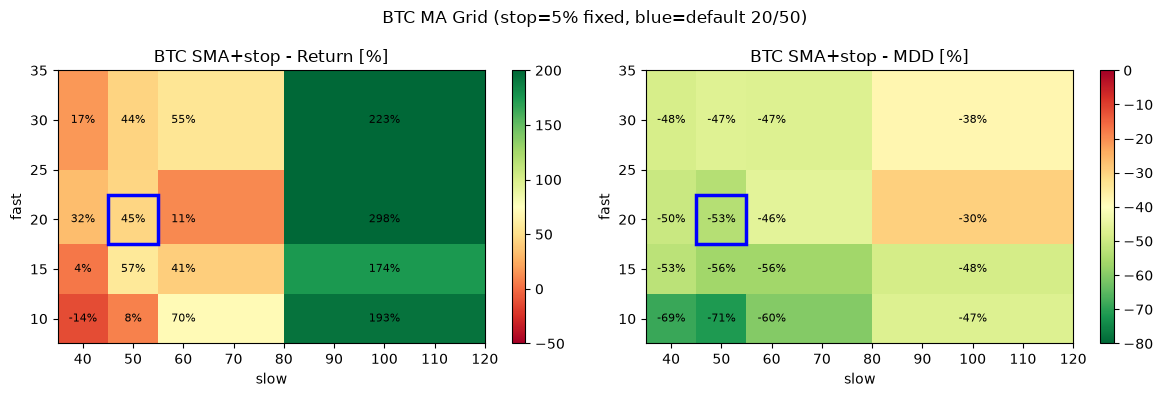

In [5]:
bh_full_btc = buy_hold(btc)
sma_grid = {"fast": [10, 15, 20, 30], "slow": [40, 50, 60, 100]}
btc_sweep = param_sweep(btc, SmaCrossWithStop, sma_grid)
btc_sweep = btc_sweep[btc_sweep["fast"] < btc_sweep["slow"]].copy()
# MDD는 음수. 전략 MDD > B&H MDD → 방어 (덜 내렸다)
btc_sweep["beats_bh_mdd"] = btc_sweep["Max. Drawdown [%]"] > bh_full_btc["Max. Drawdown [%]"]

total = len(btc_sweep)
defend_cnt = btc_sweep["beats_bh_mdd"].sum()
pos_cnt = (btc_sweep["Return [%]"] > 0).sum()
print(f"BTC MA grid ({total}조합, fast<slow, stop=5%):")
print(f"  B&H MDD 방어: {defend_cnt}/{total} ({100*defend_cnt/total:.0f}%)  수익>0: {pos_cnt}/{total}")
print(f"  → [{'PASS' if defend_cnt/total >= 0.6 else 'FAIL'}] (기준 ≥60%)")

# 히트맵
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
DEFAULT_FAST, DEFAULT_SLOW = 20, 50

ret_pivot = btc_sweep.pivot(index="fast", columns="slow", values="Return [%]")
ax = axes[0]
im0 = ax.pcolormesh(ret_pivot.columns, ret_pivot.index,
                    ret_pivot.values, cmap="RdYlGn", vmin=-50, vmax=200)
for f in ret_pivot.index:
    for s in ret_pivot.columns:
        val = ret_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow"); ax.set_ylabel("fast")
ax.set_title("BTC SMA+stop - Return [%]")
plt.colorbar(im0, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SLOW - 5, DEFAULT_FAST - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

mdd_pivot = btc_sweep.pivot(index="fast", columns="slow", values="Max. Drawdown [%]")
ax = axes[1]
im1 = ax.pcolormesh(mdd_pivot.columns, mdd_pivot.index,
                    mdd_pivot.values, cmap="RdYlGn_r", vmin=-80, vmax=0)
for f in mdd_pivot.index:
    for s in mdd_pivot.columns:
        val = mdd_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow"); ax.set_ylabel("fast")
ax.set_title("BTC SMA+stop - MDD [%]")
plt.colorbar(im1, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SLOW - 5, DEFAULT_FAST - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

plt.suptitle("BTC MA Grid (stop=5% fixed, blue=default 20/50)", fontsize=12)
plt.tight_layout()
plt.show()

### 축 3 — 워크포워드 (5구간)

In [6]:
def make_wf_table(df, strategy, k=5, **params):
    wf = walk_forward(df, strategy, k=k, **params)
    rows = []
    for _, row in wf.iterrows():
        seg = df.loc[row["start"]:row["end"]]
        bh = buy_hold(seg)
        defend = row["Max. Drawdown [%]"] > bh["Max. Drawdown [%]"]
        rows.append({
            "구간": f"seg{int(row['segment'])}",
            "기간": f"{row['start'].date()}~{row['end'].date()}",
            "봉수": len(seg),
            "전략 수익%": round(row["Return [%]"], 1),
            "전략 MDD%": round(row["Max. Drawdown [%]"], 1),
            "Sharpe":    round(row["Sharpe Ratio"], 2),
            "거래수":    int(row["# Trades"]),
            "B&H 수익%": round(bh["Return [%]"], 1),
            "B&H MDD%": round(bh["Max. Drawdown [%]"], 1),
            "낙폭방어":  "✓" if defend else "✗",
        })
    result = pd.DataFrame(rows).set_index("구간")
    defend_cnt = sum(1 for r in rows if r["낙폭방어"] == "✓")
    pos_cnt    = sum(1 for r in rows if r["전략 수익%"] > 0)
    return result, defend_cnt, pos_cnt

print("=== BTC — SmaCrossWithStop 워크포워드 (fast=20, slow=50, stop=5%) ===")
btc_wf, btc_def, btc_pos = make_wf_table(btc, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
display(btc_wf)
print(f"\n  수익>0: {btc_pos}/5구간 | 낙폭방어: {btc_def}/5구간")
print(f"  → [{'PASS' if btc_def >= 3 else 'FAIL'}] (기준 ≥3/5구간)")

=== BTC — SmaCrossWithStop 워크포워드 (fast=20, slow=50, stop=5%) ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,,
seg0,2021-06-28~2022-06-28,2189,-3.8,-35.9,-0.1,23,-39.0,-73.6,✓
seg1,2022-06-28~2023-06-28,2190,11.4,-32.9,0.3,22,47.1,-36.8,✓
seg2,2023-06-28~2024-06-27,2190,52.7,-24.2,1.0,22,101.2,-22.4,✗
seg3,2024-06-27~2025-06-27,2190,10.7,-32.7,0.3,25,73.7,-30.6,✗
seg4,2025-06-27~2026-06-27,2190,-15.1,-33.9,-0.8,25,-43.7,-52.7,✓



  수익>0: 3/5구간 | 낙폭방어: 3/5구간
  → [PASS] (기준 ≥3/5구간)


---

## ETH 검증 (out-of-asset)

BTC에서 사용한 파라미터(20/50/5%) 그대로 ETH 4h에 적용. 동일 기준 3축.

### 축 1 — OOS

In [7]:
eth_train, eth_test = train_test_split(eth, 0.7)

print("=== ETH — SmaCrossWithStop (fast=20, slow=50, stop=5%) ===")
eth_oos = make_oos_table(eth, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
display(eth_oos)

bh_eth_oos = buy_hold(eth_test)
stop_eth_oos = evaluate(eth_test, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
defend_eth = stop_eth_oos["Max. Drawdown [%]"] - bh_eth_oos["Max. Drawdown [%]"]
print(f"\n축1 OOS 낙폭방어: {defend_eth:+.1f}%p  → [{'PASS' if defend_eth > 0 else 'FAIL'}]")

=== ETH — SmaCrossWithStop (fast=20, slow=50, stop=5%) ===


,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어%p
구간,,,,,,,,
FULL (2021-06-29~2026-06-28),10949,50.5,-45.6,0.2,127,-27.6,-81.1,35.5
IS 앞70% (2021-06-29~2024-12-27),7664,50.2,-45.6,0.2,89,52.8,-81.1,35.5
OOS 뒤30% (2024-12-27~2026-06-28),3285,3.5,-40.3,0.1,36,-53.1,-68.0,27.8



축1 OOS 낙폭방어: +27.8%p  → [PASS]


### 축 2a — 손절 민감도 (ETH)

In [8]:
bh_full_eth = buy_hold(eth)
ss_eth = param_sweep(eth, SmaCrossWithStop, {"stop_loss_pct": [0.03, 0.05, 0.08]})
rows_eth = []
for _, r in ss_eth.iterrows():
    defend_pp = r["Max. Drawdown [%]"] - bh_full_eth["Max. Drawdown [%]"]
    rows_eth.append({
        "stop": f"{r['stop_loss_pct']*100:.0f}%",
        "수익%":  round(r["Return [%]"], 1),
        "MDD%":  round(r["Max. Drawdown [%]"], 1),
        "Sharpe": round(r["Sharpe Ratio"], 2),
        "거래수": int(r["# Trades"]),
        "낙폭방어%p": round(defend_pp, 1),
        "방어여부": "✓" if defend_pp > 0 else "✗",
    })
ss_eth_df = pd.DataFrame(rows_eth).set_index("stop")
print(f"=== ETH 손절 민감도 (B&H MDD 기준: {bh_full_eth['Max. Drawdown [%]']:+.1f}%) ===")
display(ss_eth_df)
pass_cnt_eth = sum(1 for r in rows_eth if r["방어여부"] == "✓")
print(f"\n방어: {pass_cnt_eth}/3  → [{'PASS' if pass_cnt_eth >= 2 else 'FAIL'}]")

=== ETH 손절 민감도 (B&H MDD 기준: -81.1%) ===


,수익%,MDD%,Sharpe,거래수,낙폭방어%p,방어여부
stop,,,,,,
3%,67.3,-33.3,0.3,127,47.8,✓
5%,50.5,-45.6,0.2,127,35.5,✓
8%,-28.1,-62.5,-0.1,127,18.6,✓



방어: 3/3  → [PASS]


### 축 2b — MA grid 히트맵 (ETH, stop=5%)

ETH MA grid (16조합, fast<slow, stop=5%):
  B&H MDD 방어: 16/16 (100%)  수익>0: 14/16
  → [PASS] (기준 ≥60%)


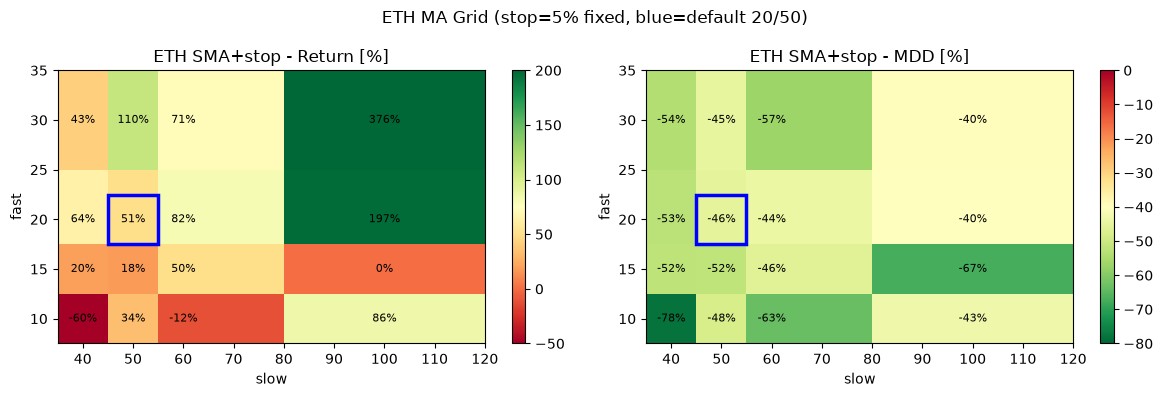

In [9]:
bh_full_eth = buy_hold(eth)
eth_sweep = param_sweep(eth, SmaCrossWithStop, sma_grid)
eth_sweep = eth_sweep[eth_sweep["fast"] < eth_sweep["slow"]].copy()
eth_sweep["beats_bh_mdd"] = eth_sweep["Max. Drawdown [%]"] > bh_full_eth["Max. Drawdown [%]"]

total_eth = len(eth_sweep)
defend_eth_grid = eth_sweep["beats_bh_mdd"].sum()
pos_eth_grid = (eth_sweep["Return [%]"] > 0).sum()
print(f"ETH MA grid ({total_eth}조합, fast<slow, stop=5%):")
print(f"  B&H MDD 방어: {defend_eth_grid}/{total_eth} ({100*defend_eth_grid/total_eth:.0f}%)  수익>0: {pos_eth_grid}/{total_eth}")
print(f"  → [{'PASS' if defend_eth_grid/total_eth >= 0.6 else 'FAIL'}] (기준 ≥60%)")

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

ret_eth_pivot = eth_sweep.pivot(index="fast", columns="slow", values="Return [%]")
ax = axes[0]
im2 = ax.pcolormesh(ret_eth_pivot.columns, ret_eth_pivot.index,
                    ret_eth_pivot.values, cmap="RdYlGn", vmin=-50, vmax=200)
for f in ret_eth_pivot.index:
    for s in ret_eth_pivot.columns:
        val = ret_eth_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow"); ax.set_ylabel("fast")
ax.set_title("ETH SMA+stop - Return [%]")
plt.colorbar(im2, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SLOW - 5, DEFAULT_FAST - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

mdd_eth_pivot = eth_sweep.pivot(index="fast", columns="slow", values="Max. Drawdown [%]")
ax = axes[1]
im3 = ax.pcolormesh(mdd_eth_pivot.columns, mdd_eth_pivot.index,
                    mdd_eth_pivot.values, cmap="RdYlGn_r", vmin=-80, vmax=0)
for f in mdd_eth_pivot.index:
    for s in mdd_eth_pivot.columns:
        val = mdd_eth_pivot.loc[f, s]
        if not np.isnan(val):
            ax.text(s, f, f"{val:.0f}%", ha="center", va="center", fontsize=8, color="black")
ax.set_xlabel("slow"); ax.set_ylabel("fast")
ax.set_title("ETH SMA+stop - MDD [%]")
plt.colorbar(im3, ax=ax)
ax.add_patch(mpatches.Rectangle(
    (DEFAULT_SLOW - 5, DEFAULT_FAST - 2.5), 10, 5,
    linewidth=2.5, edgecolor="blue", facecolor="none", zorder=5
))

plt.suptitle("ETH MA Grid (stop=5% fixed, blue=default 20/50)", fontsize=12)
plt.tight_layout()
plt.show()

### 축 3 — 워크포워드 (ETH, 5구간)

In [10]:
print("=== ETH — SmaCrossWithStop 워크포워드 (fast=20, slow=50, stop=5%) ===")
eth_wf, eth_def, eth_pos = make_wf_table(eth, SmaCrossWithStop, fast=20, slow=50, stop_loss_pct=0.05)
display(eth_wf)
print(f"\n  수익>0: {eth_pos}/5구간 | 낙폭방어: {eth_def}/5구간")
print(f"  → [{'PASS' if eth_def >= 3 else 'FAIL'}] (기준 ≥3/5구간)")

=== ETH — SmaCrossWithStop 워크포워드 (fast=20, slow=50, stop=5%) ===


,기간,봉수,전략 수익%,전략 MDD%,Sharpe,거래수,B&H 수익%,B&H MDD%,낙폭방어
구간,,,,,,,,,
seg0,2021-06-29~2022-06-29,2189,19.8,-34.0,0.3,24,-47.4,-81.1,✓
seg1,2022-06-29~2023-06-29,2190,12.9,-29.0,0.2,25,62.6,-46.2,✓
seg2,2023-06-29~2024-06-28,2190,51.6,-27.7,0.8,24,87.3,-29.4,✓
seg3,2024-06-28~2025-06-28,2190,-23.8,-39.3,-0.7,26,-29.5,-65.1,✓
seg4,2025-06-28~2026-06-28,2190,-20.6,-40.3,-0.8,23,-35.2,-68.0,✓



  수익>0: 3/5구간 | 낙폭방어: 5/5구간
  → [PASS] (기준 ≥3/5구간)


---

## 판정

**결론: SmaCrossWithStop — BTC+ETH 3축 통과 (검증된 2번째 후보)**

### 손절이 해소한 두 탈락 사유
1. **리스크룰 부재 (가드레일 5)** → 손절 5% 추가로 해소
2. **방어 일관성 부족** → BTC 워크포워드 2/5 → 3/5, ETH 5/5 (BTC보다 강함)

### 통과에 붙는 단서 (반드시 명시)
- **Donchian과 같은 4h 추세추종 계열 → 독립 알파 아님.**
  포트폴리오 분산 가치 제한적. Phase 4에서는 Donchian의 대체/보조 후보로만 취급.
  (통과해도 "후보 2개"이지 "분산된 포트폴리오"가 아니다.)
- **손절 값에 민감.** 더 타이트할수록(3%) 좋았고 ETH에선 8%가 음수.
  5%는 사전 고정한 합리적 값이며 3% best는 곡선맞추기라 채택 안 함.
- **여전히 B&H 총수익은 못 이김** (BTC +45% vs B&H +75%) — Donchian과 동일하게 "방어 도구".

### 정직한 한계
- BTC·ETH 둘 다 크립토 베타라 상관 높음 (완전 독립 검증 아님).
  ETH가 약세장이라 방어가 잘 보인 면도 있음.
- 손절이 결과를 크게 바꾼 만큼 "손절 파라미터" 자체가 새로운 자유도.
  5%로 사전 고정해 곡선맞추기는 피했으나, 향후 과신 금물.